# LOCAT Tutorial: gene localization in PBMC3K

## Overview
This tutorial walks through the full LOCAT workflow on the PBMC3K dataset, a RNA-Seq dataset of 3,000 peripheral blood mononuclear cells (PBMCs) from a healthy donor (10x Genomics). LOCAT  identifies genes whose expression is spatially structured in the cell landscape, focusing in particular on those that are concentrated in a specific region and depleted elsewhere.

That means we will:
1. Load the preprocessed PBMC3K object from `scanpy.datasets.pbmc3k_processed()`
2. Extract the raw data matrix and filter genes
3. Run Locat to score every gene for spatial concentration and depletion
4. Describe the results of the LOCAT analysis
5. Visualize the top concentrated and top concentrated-and-depleted genes


In [1]:
import numpy as np
import pandas as pd
import scanpy as sc

from locat.locat import LOCAT
from locat.postprocessing import build_locat_df
from locat.preprocessing import filter_genes, get_embedding
from locat.plotting_and_other_methods import plot_grid

LOCAT uses [JAX](https://jax.readthedocs.io/) for GPU-accelerated computation.

If a GPU is available it will be used automatically.
If a GPU is not detected, JAX runs on the CPU, which is slower but provides the same results.

In [2]:
import jax
import locat

print(f"locat version:  {locat.__version__}")
print(f"JAX version:    {jax.__version__}")
print(f"JAX backend:    {jax.default_backend()}")
print(f"JAX devices:    {jax.devices()}")

locat version:  0.1.5.dev3+ge9c813317.d20260404
JAX version:    0.6.2
JAX backend:    gpu
JAX devices:    [CudaDevice(id=0)]


## Preprocessing

We use the [Scanpy PBMC3K dataset](https://scanpy.readthedocs.io/en/latest/tutorials/basics/clustering-2017.html): 3,000 peripheral blood mononuclear cells (PBMCs) from a healthy donor (10x Genomics), covering eight immune cell types — CD4+ and CD8+ T cells, B cells, NK cells, CD14+ and FCGR3A+ monocytes, dendritic cells, and megakaryocytes. After quality control, the object contains 2,638 cells.

We use [`pbmc3k_processed`](https://scanpy.readthedocs.io/en/latest/generated/scanpy.datasets.pbmc3k_processed.html#scanpy.datasets.pbmc3k_processed) because it is a well-known benchmark dataset and  it stores a PCA we want to reuse as the LOCAT embedding. We will not use the Scanpy-processed gene matrix — instead we recover the raw counts from `.raw` and apply our own minimal filtering, so that LOCAT can score the full gene universe rather than just the highly variable genes.

The function `sc.datasets.pbmc3k_processed()` will download the dataset to the file `data/pbmc3k_processed.h5ad` if not already existing. If you wish to change the location where the file is stored, run `sc.settings.datasetdir = Path("/data/location/")`.

In [3]:
adata_pbmc3k_processed = sc.datasets.pbmc3k_processed()
adata_pbmc3k = adata_pbmc3k_processed.raw.to_adata()
adata_pbmc3k

AnnData object with n_obs × n_vars = 2638 × 13714
    obs: 'n_genes', 'percent_mito', 'n_counts', 'louvain'
    var: 'n_cells'
    uns: 'draw_graph', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'X_draw_graph_fr'
    obsp: 'distances', 'connectivities'

Next, we apply `filter_genes` to remove two classes of genes that carry little localization signal:
- **Pseudogene-like symbols** matched by name patterns (e.g. `Gm*`, `*Rik`, `Linc*`, ribosomal duplicates) — these are typically unannotated or non-coding loci
- **Very lowly expressed genes** present in fewer than 1% of cells — too noisy and sparse for being biologically relevant since they are only expressed in a hanful of cells

In [4]:
n_before = adata_pbmc3k.n_vars
adata_locat = filter_genes(adata_pbmc3k)
print(f"Genes retained: {adata_locat.n_vars} / {n_before}")

Genes retained: 8859 / 13714


## Run LOCAT

LOCAT fits a Gaussian mixture model (GMM) to the cell embedding and scores each gene by comparing how expressing cells are distributed in space against the background distribution of all cells. It returns a `locat_df` table with one row per gene.

**`LOCAT(...)` — model setup**

- `cell_embedding`: the PCA coordinates used as the cell space — here the first 8 PCs, which capture the main structure of the PBMC populations
- `knn_mode="connectivity"`: use the Scanpy neighbor graph edge weights (soft connectivity) rather than binary presence/absence, giving a smoother local density estimate
- `n_bootstrap_inits=10`: number of random GMM initialisations per bootstrap sample — reduced from the default (50) for speed; increase for a more thorough analysis
- `reg_covar=1e-6`: small value added to the GMM covariance diagonal for numerical stability

**`gmm_scan(...)` — gene scoring**

- `rc_lambda_values`: the grid of concentration factors scanned by the depletion test — a coarser grid (`linspace(1, 2, 8)`) is used here for speed; revert to default for a more thorough analysis


In [5]:
model = LOCAT(
    adata=adata_locat,
    cell_embedding=get_embedding(adata_locat, n_dims=8),
    n_bootstrap_inits=10,
    show_progress=True,
    knn_mode="connectivity",
    reg_covar=1e-6,
)

locat_df = build_locat_df(model.gmm_scan(
    rc_lambda_values=np.linspace(1.0, 2.0, 8),
))

2026-04-06 10:22:03.752 | INFO     | locat.locat:background_pdf:438 - fitting background PDF
2026-04-06 10:22:03.752 | INFO     | locat.locat:background_n_components_init:208 - Estimating number of GMM components
estimating BIC for 51 cells: 100%|██████████| 30/30 [00:00<00:00, 35.61it/s]
2026-04-06 10:22:11.501 | INFO     | locat.locat:background_pdf:450 - Using 5 components
fitting background: 100%|██████████| 10/10 [00:00<00:00, 71.69it/s]
null distribution parameters (perm. pseudo-genes):   0%|          | 0/7 [00:00<?, ?it/s]2026-04-06 10:22:11.781 | INFO     | locat.locat:min_dist:144 - recomputing min cell-cell distance
2026-04-06 10:22:11.782 | INFO     | locat.locat:cell_dist:136 - recomputing cell-cell distance
null distribution parameters (perm. pseudo-genes): 100%|██████████| 7/7 [00:05<00:00,  1.22it/s]
scanning genes: 100%|██████████| 8859/8859 [01:31<00:00, 96.45it/s] 


## Results

`build_locat_df` converts the raw LOCAT output into a tidy DataFrame with one row per gene. Genes are sorted by combined p-value so the most significant appear first.

**Concentration (is a gene clustered in space?)**

- `zscore`: how much more concentrated the gene's expressing cells are compared to the background GMM — higher means more clustered
- `concentration_pval`: p-value for the concentration test
- `is_conc_sig`: `True` if `concentration_pval < 0.05`

**Depletion (is a gene absent from some regions?)**

- `depletion_pval`: p-value for the depletion test — tests whether the gene is significantly under-represented in at least one spatial region
- `max_deficit`: the largest gap between the expected and observed fraction of expressing cells across all scanned regions — a direct measure of depletion strength
- `is_depl_sig`: `True` if `depletion_pval < 0.05`

**Combined**

- `pval`: combined p-value integrating concentration and depletion signals
- `is_joint_sig`: `True` if `pval < 0.05`


All columns are described in the [`LocatResult` documentation](https://klugerlab.github.io/Locat/reference/locat.locat_result.html).

In [6]:
locat_df.head(10)

,gene_name,bic,zscore,sens_score,depletion_pval,concentration_pval,h_size,h_sens,pval,K_components,sample_size,max_deficit,is_conc_sig,is_depl_sig,is_joint_sig
gene,,,,,,,,,,,,,,,
RNASE2,RNASE2,5.9579,7.328457,1.0,0.0,0.0,0.016529,0.0,0.000826,2,59.0,0.991961,True,True,True
RP5-887A10.1,RP5-887A10.1,-3208566051.172291,3.904195,1.0,0.0,0.000047,0.027396,0.0,0.00137,2,35.0,0.9801,True,True,True
ICAM4,ICAM4,8.699026,3.790885,1.0,0.0,0.000075,0.027396,0.0,0.00137,2,35.0,0.96951,True,True,True
BACE2,BACE2,-5889761859.259194,3.591428,1.0,0.0,0.000164,0.028983,0.0,0.001449,2,33.0,0.980948,True,True,True
RP11-428G5.5,RP11-428G5.5,-11592630.901236,3.46296,1.0,0.0,0.000267,0.030767,0.0,0.001538,2,31.0,0.983796,True,True,True
MYOF,MYOF,9.55608,3.367864,1.0,0.0,0.000379,0.030767,0.0,0.001538,2,31.0,0.994927,True,True,True
FXYD6,FXYD6,9.660164,3.364742,1.0,0.0,0.000383,0.030767,0.0,0.001538,2,31.0,0.993377,True,True,True
OSBPL10,OSBPL10,8.539526,3.326886,1.0,0.0,0.000439,0.031743,0.0,0.001587,2,30.0,0.972077,True,True,True
ARHGEF10L,ARHGEF10L,10.056512,3.044539,1.0,0.0,0.001165,0.032784,0.0,0.001639,2,29.0,0.993925,True,True,True


Next, we count significant genes (p < 0.05) in each category.

In [7]:
summary = pd.Series({
    "genes_scored": int(locat_df.shape[0]),
    "conc_sig":     int(locat_df["is_conc_sig"].sum()),
    "depl_sig":     int(locat_df["is_depl_sig"].sum()),
    "joint_sig":    int(locat_df["is_joint_sig"].sum()),
    "conc_only":    int((locat_df["is_conc_sig"] & ~locat_df["is_depl_sig"]).sum()),
    "conc_depl":    int((locat_df["is_conc_sig"] &  locat_df["is_depl_sig"]).sum()),
})
display(summary.to_frame("count"))

,count
genes_scored,8754
conc_sig,1827
depl_sig,8625
joint_sig,541
conc_only,90
conc_depl,1737


## Top genes

A key feature of LOCAT is that it identifies genes that are not only concentrated in a specific region but also depleted elsewhere. Genes that are also depleted tend to be more specific markers of that region.

We select the top 6 genes from each category and visualize their expression on the UMAP.

**Concentration-only** genes are significantly enriched in a specific region but are not absent from others. These tend to mark a cell type or state without being strictly excluded elsewhere. We rank by concentration strength (`zscore`).

In [8]:
genes_conc_only = (locat_df[locat_df["is_conc_sig"] & ~locat_df["is_depl_sig"]]
    .sort_values(["zscore", "max_deficit", "concentration_pval"], ascending=[False, False, True])
    .index[:6])
locat_df.loc[genes_conc_only, ["zscore", "concentration_pval", "depletion_pval", "max_deficit", "sample_size"]]

,zscore,concentration_pval,depletion_pval,max_deficit,sample_size
gene,,,,,
IL7R,12.4369,0.0,0.269713,0.073749,1062.0
CXCR4,10.344442,0.0,0.109393,0.120904,1585.0
LCK,10.005871,0.0,1.0,-0.038012,953.0
MAL,9.787817,0.0,1.0,-0.013983,353.0
CD27,9.176478,0.0,1.0,-0.15102,632.0
PRKCQ-AS1,8.890096,0.0,1.0,-0.117591,445.0


**Concentration-plus-depletion** genes are both enriched in one region and absent from others — the strongest signature of spatial localization. We rank by depletion strength (`max_deficit`), which measures how large the gap is between where the gene is expected and where it is actually expressed.

In [9]:
genes_conc_depl = (locat_df[locat_df["is_conc_sig"] & locat_df["is_depl_sig"]]
    .sort_values(["max_deficit", "depletion_pval", "concentration_pval"], ascending=[False, True, True])
    .index[:6])
locat_df.loc[genes_conc_depl, ["zscore", "concentration_pval", "depletion_pval", "max_deficit", "sample_size"]]

,zscore,concentration_pval,depletion_pval,max_deficit,sample_size
gene,,,,,
VMO1,3.141256,0.000841,0.0,0.998259,29.0
MYOF,3.367864,0.000379,0.0,0.994927,31.0
TNNT1,3.126928,0.000883,0.0,0.994738,32.0
ARHGEF10L,3.044539,0.001165,0.0,0.993925,29.0
FXYD6,3.364742,0.000383,0.0,0.993377,31.0
RNASE2,7.328457,0.0,0.0,0.991961,59.0


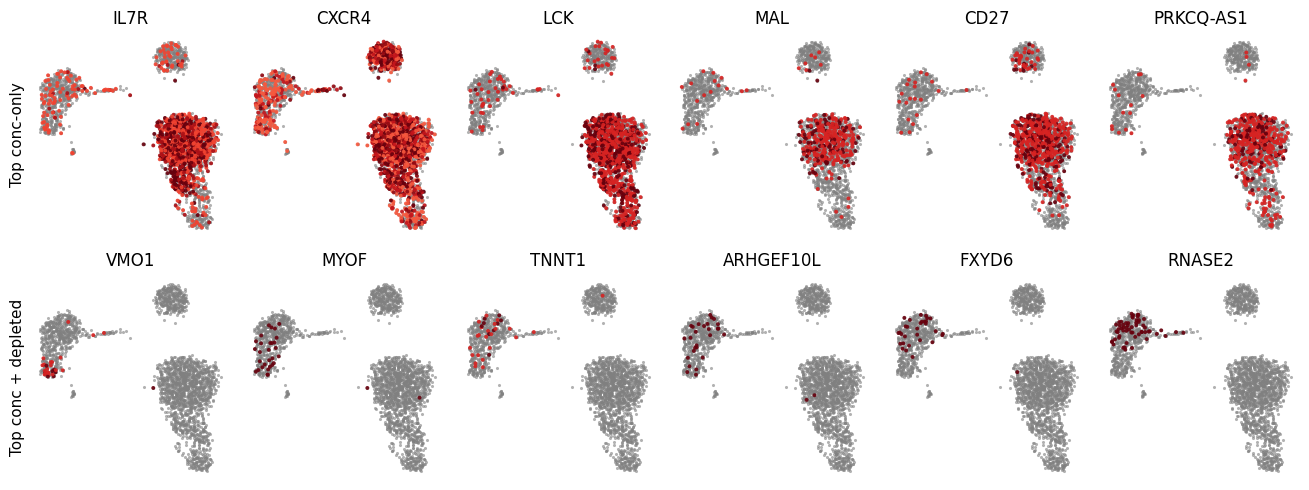

In [10]:
fig = plot_grid(
    adata_locat,
    gene_lists=[genes_conc_only, genes_conc_depl],
    titles=["Top conc-only", "Top conc + depleted"],
)

## Exporting results
The results table can be exported as a CSV and the figure as an SVG.

In [11]:
locat_df[["zscore", "concentration_pval", "depletion_pval", "pval", "max_deficit", "sample_size", "K_components"]]\
    .to_csv("PBMC_locat_results.csv")

In [12]:
fig.savefig("locat_top_genes.svg", bbox_inches="tight")